# Two-View Adversarial Consistency with GAIRAT, AWP, and EMA

This notebook improves adversarial robustness by combining two-view augmentation, GAIRAT-TRADES training, adversarial weight perturbation (AWP), and exponential moving average (EMA).

In [1]:
from pathlib import Path
import os

RUN_ON_DRIVE = False

PROJECT_NAME = "adversarial_attacks_and_defenses"


In [2]:
if RUN_ON_DRIVE:
    try:
        from google.colab import drive
    except ImportError as exc:
        raise RuntimeError(
            "RUN_ON_DRIVE=True requires Google Colab. "
            "Set RUN_ON_DRIVE=False for local execution."
        ) from exc

    DRIVE_MOUNT_DIR = Path("/content/drive")
    drive.mount(
        str(DRIVE_MOUNT_DIR),
        force_remount=False
    )

    PROJECT_DIR = (
        DRIVE_MOUNT_DIR
        / "MyDrive"
        / PROJECT_NAME
    )

else:
    current_dir = Path.cwd().resolve()

    PROJECT_DIR = (
        current_dir
        if current_dir.name == PROJECT_NAME
        else current_dir / PROJECT_NAME
    )

PROJECT_DIR = PROJECT_DIR.resolve()

DATA_DIR = PROJECT_DIR / "data"
CHECKPOINTS_DIR = PROJECT_DIR / "checkpoints"
RESULTS_DIR = PROJECT_DIR / "results"
CACHE_DIR = PROJECT_DIR / "cache"

HF_HOME_DIR = CACHE_DIR / "huggingface"
TORCH_HOME_DIR = CACHE_DIR / "torch"

for directory in (
    PROJECT_DIR,
    DATA_DIR,
    CHECKPOINTS_DIR,
    RESULTS_DIR,
    CACHE_DIR,
    HF_HOME_DIR,
    TORCH_HOME_DIR,
):
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

os.environ["HF_HOME"] = str(HF_HOME_DIR)
os.environ["HF_HUB_CACHE"] = str(
    HF_HOME_DIR / "hub"
)
os.environ["TORCH_HOME"] = str(
    TORCH_HOME_DIR
)

print(f"RUN_ON_DRIVE  : {RUN_ON_DRIVE}")
print(f"PROJECT_DIR   : {PROJECT_DIR}")
print(f"DATA_DIR      : {DATA_DIR}")
print(f"CHECKPOINTS   : {CHECKPOINTS_DIR}")
print(f"RESULTS_DIR   : {RESULTS_DIR}")
print(f"HF_HOME       : {os.environ['HF_HOME']}")
print(f"TORCH_HOME    : {os.environ['TORCH_HOME']}")

RUN_ON_DRIVE  : False
PROJECT_DIR   : /home/ali/Desktop/SUT/AI/adversarial_attacks_and_defenses
DATA_DIR      : /home/ali/Desktop/SUT/AI/adversarial_attacks_and_defenses/data
CHECKPOINTS   : /home/ali/Desktop/SUT/AI/adversarial_attacks_and_defenses/checkpoints
RESULTS_DIR   : /home/ali/Desktop/SUT/AI/adversarial_attacks_and_defenses/results
HF_HOME       : /home/ali/Desktop/SUT/AI/adversarial_attacks_and_defenses/cache/huggingface
TORCH_HOME    : /home/ali/Desktop/SUT/AI/adversarial_attacks_and_defenses/cache/torch


In [3]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [5]:
RANDOM_SEED = 42
set_seed(RANDOM_SEED)

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## CIFAR-10 Data Preparation

Each training image produces two independently augmented views. Validation and test images remain unaugmented in the `[0,1]` pixel space.

In [7]:
BATCH_SIZE = 128
NUM_WORKERS = 2

DATA_ROOT = DATA_DIR / "cifar10"
DATA_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

VAL_SIZE = 5000

PIN_MEMORY = torch.cuda.is_available()

print("CIFAR-10 root:", DATA_ROOT)

CIFAR-10 root: /home/ali/Desktop/SUT/AI/adversarial_attacks_and_defenses/data/cifar10


In [8]:
class Cutout:
    def __init__(self, size=16):
        if size <= 0:
            raise ValueError(
                "Cutout size must be positive."
            )

        self.size = int(size)

    def __call__(self, image_tensor):
        if image_tensor.ndim != 3:
            raise ValueError(
                "Cutout expects a CHW image tensor."
            )

        _, height, width = image_tensor.shape

        center_y = torch.randint(
            low=0,
            high=height,
            size=(1,)
        ).item()

        center_x = torch.randint(
            low=0,
            high=width,
            size=(1,)
        ).item()

        half_size = self.size // 2

        y_start = max(
            center_y - half_size,
            0
        )
        y_end = min(
            y_start + self.size,
            height
        )

        x_start = max(
            center_x - half_size,
            0
        )
        x_end = min(
            x_start + self.size,
            width
        )

        output = image_tensor.clone()

        output[
            :,
            y_start:y_end,
            x_start:x_end
        ] = 0.0

        return output


train_transform = transforms.Compose([
    transforms.RandomCrop(
        32,
        padding=4
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply(
        [
            transforms.ColorJitter(
                brightness=0.4,
                contrast=0.4,
                saturation=0.4,
                hue=0.1
            )
        ],
        p=0.8
    ),
    transforms.RandomGrayscale(
        p=0.2
    ),
    transforms.ToTensor(),
    Cutout(
        size=16
    )
])

raw_transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_base_dataset = (
    torchvision.datasets.CIFAR10(
        root=DATA_ROOT,
        train=True,
        download=True,
        transform=None
    )
)

full_train_raw_dataset = (
    torchvision.datasets.CIFAR10(
        root=DATA_ROOT,
        train=True,
        download=True,
        transform=raw_transform
    )
)

test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=raw_transform
)

CIFAR10_CLASSES = (
    full_train_raw_dataset.classes
)


In [9]:
class TwoViewSubset(
    torch.utils.data.Dataset
):
    def __init__(
        self,
        dataset,
        indices,
        transform
    ):
        self.dataset = dataset
        self.indices = [
            int(index)
            for index in indices
        ]
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        dataset_index = self.indices[position]

        image, label = self.dataset[
            dataset_index
        ]

        view_one = self.transform(image)
        view_two = self.transform(image)

        return (
            view_one,
            view_two,
            label
        )


num_train = len(
    full_train_raw_dataset
)

indices = torch.randperm(
    num_train,
    generator=torch.Generator().manual_seed(
        RANDOM_SEED
    )
)

val_indices = indices[:VAL_SIZE]
train_indices = indices[VAL_SIZE:]

train_dataset = TwoViewSubset(
    dataset=full_train_base_dataset,
    indices=train_indices,
    transform=train_transform
)

val_dataset = torch.utils.data.Subset(
    full_train_raw_dataset,
    val_indices
)

mean_std_dataset = torch.utils.data.Subset(
    full_train_raw_dataset,
    train_indices
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

mean_std_loader = (
    torch.utils.data.DataLoader(
        mean_std_dataset,
        batch_size=512,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )
)

print(
    "Training samples:",
    len(train_dataset)
)

print(
    "Validation samples:",
    len(val_dataset)
)

print(
    "Test samples:",
    len(test_dataset)
)


Training samples: 45000
Validation samples: 5000
Test samples: 10000


## ResNet20 Model

Normalization is placed inside ResNet20 so adversarial perturbations can be generated directly in the original pixel space.

$$
x_{\mathrm{norm}}=\frac{x-\mu}{\sigma}
$$

In [10]:
class Normalize(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        mean = torch.tensor(mean).view(1, 3, 1, 1)
        std = torch.tensor(std).view(1, 3, 1, 1)
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        return (x - self.mean) / self.std

In [11]:
def compute_mean_std(loader):
    channels_sum = torch.zeros(3)
    channels_squared_sum = torch.zeros(3)
    num_pixels = 0

    for images, _ in loader:
        batch_size, channels, height, width = images.shape

        num_pixels += batch_size * height * width

        channels_sum += images.sum(dim=[0, 2, 3])
        channels_squared_sum += (images ** 2).sum(dim=[0, 2, 3])

    mean = channels_sum / num_pixels

    std = torch.sqrt(channels_squared_sum / num_pixels - mean ** 2)

    return mean, std

In [12]:
cifar10_mean, cifar10_std = compute_mean_std(mean_std_loader)

cifar10_mean = cifar10_mean.tolist()
cifar10_std = cifar10_std.tolist()

print("Mean:", cifar10_mean)
print("Std:", cifar10_std)

Mean: [0.4913501441478729, 0.4821614623069763, 0.44659730792045593]
Std: [0.24704869091510773, 0.24355383217334747, 0.26168447732925415]


In [13]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + self.shortcut(x)
        out = F.relu(out)

        return out

In [14]:
class ResNet20(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 16

        self.conv1 = nn.Conv2d(
            3,
            16,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(16)

        self.layer1 = self._make_layer(
            out_channels=16,
            num_blocks=3,
            stride=1
        )

        self.layer2 = self._make_layer(
            out_channels=32,
            num_blocks=3,
            stride=2
        )

        self.layer3 = self._make_layer(
            out_channels=64,
            num_blocks=3,
            stride=2
        )

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

        self._initialize_weights()

    def _make_layer(self, out_channels, num_blocks, stride):
        layers = []

        layers.append(
            BasicBlock(
                in_channels=self.in_channels,
                out_channels=out_channels,
                stride=stride
            )
        )

        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            layers.append(
                BasicBlock(
                    in_channels=self.in_channels,
                    out_channels=out_channels,
                    stride=1
                )
            )

        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(
                    module.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.01)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)

        out = self.avg_pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)

        return out

In [15]:
def build_resnet20_model(
    cifar10_mean,
    cifar10_std,
    device,
    num_classes=10
):
    resnet20 = ResNet20(num_classes=num_classes)

    model = nn.Sequential(
        Normalize(cifar10_mean, cifar10_std),
        resnet20
    ).to(device)

    return model

In [16]:
model = build_resnet20_model(
    cifar10_mean=cifar10_mean,
    cifar10_std=cifar10_std,
    device=device,
    num_classes=len(CIFAR10_CLASSES)
)

print(model)

Sequential(
  (0): Normalize()
  (1): ResNet20(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (shortcut): Sequential()
      )
      (1): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=

## C&W L2 Attack

The C&W attack searches for a small L2 perturbation that changes the model prediction:

$$
\min_{\delta}\|\delta\|_2^2+c\,f(x+\delta)
$$

In [17]:
CW_C = 1.0
CW_KAPPA = 0.0
CW_LEARNING_RATE = 0.01

CW_VAL_STEPS = 100
CW_TEST_STEPS = 100

In [18]:
def atanh(x):
    return 0.5 * torch.log((1 + x) / (1 - x))

In [19]:
def image_to_tanh_space(images, eps=1e-6):
    images = torch.clamp(images, eps, 1 - eps)
    return atanh(2 * images - 1)

In [20]:
def tanh_space_to_image(w):
    return 0.5 * (torch.tanh(w) + 1)

In [21]:
def cw_attack(
    model,
    images,
    labels,
    c,
    kappa,
    num_steps,
    lr,
    device
):
    model.eval()

    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)

    batch_size = images.size(0)

    w = image_to_tanh_space(images).detach()
    w.requires_grad = True

    optimizer = torch.optim.Adam([w], lr=lr)

    best_adv_images = images.clone().detach()

    best_l2 = torch.full(
        (batch_size,),
        float("inf"),
        device=device
    )

    best_success = torch.zeros(
        batch_size,
        dtype=torch.bool,
        device=device
    )

    for step in range(num_steps + 1):
        adv_images = tanh_space_to_image(w)

        logits = model(adv_images)

        one_hot_labels = F.one_hot(
            labels,
            num_classes=logits.size(1)
        ).bool()

        true_logits = logits.gather(
            1,
            labels.view(-1, 1)
        ).squeeze(1)

        wrong_logits = logits.masked_fill(
            one_hot_labels,
            -float("inf")
        )

        max_wrong_logits = wrong_logits.max(dim=1).values

        f_loss = torch.clamp(
            true_logits - max_wrong_logits,
            min=-kappa
        )

        l2_loss_per_sample = torch.sum(
            (adv_images - images) ** 2,
            dim=[1, 2, 3]
        )

        with torch.no_grad():
            preds = logits.argmax(dim=1)
            success = preds != labels

            improved = (
                success
                & (l2_loss_per_sample < best_l2)
            )

            best_l2[improved] = l2_loss_per_sample[improved]

            best_adv_images[improved] = (
                adv_images[improved].detach()
            )

            best_success[improved] = True

        if step == num_steps:
            break

        loss = l2_loss_per_sample + c * f_loss
        loss = loss.sum()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    final_adv_images = best_adv_images.detach().clone()

    with torch.no_grad():
        final_logits = model(final_adv_images)
        final_preds = final_logits.argmax(dim=1)

    return (
        final_adv_images,
        best_success,
        best_l2,
        final_preds
    )

## Two-View GAIRAT-TRADES Consistency

Two adversarial views are generated using PGD-10 and weighted independently with GAIRAT. A consistency loss encourages similar adversarial predictions for both views.

$$
L=
\frac{
L_{\mathrm{GAIRAT\text{-}TRADES}}^{(1)}
+
L_{\mathrm{GAIRAT\text{-}TRADES}}^{(2)}
}{2}
+
\lambda_{\mathrm{cons}}
\operatorname{JS}(p_1,p_2)
$$

In [22]:
TRADES_EPSILON = 0.031
TRADES_STEP_SIZE = 0.007
TRADES_PERTURB_STEPS = 10

WEIGHTING_MODE = "gairat"
WEIGHTING_START_EPOCH = 10
GAIRAT_LAMBDA = 0.0


## Adversarial Weight Perturbation

AWP temporarily perturbs the model weights toward a direction that increases the adversarial training loss, improving robustness during optimization.

In [23]:
AWP_GAMMA = 5e-3
AWP_WARMUP_EPOCHS = 15
AWP_NUM_STEPS = 1
AWP_PROXY_LR = 0.1

AWP_EPS = 1e-20
CONSISTENCY_WEIGHT = 1.0
CONSISTENCY_TEMPERATURE = 0.5


In [24]:
def diff_in_weights(
    model,
    proxy_model,
    eps=AWP_EPS
):

    model_parameters = dict(
        model.named_parameters()
    )

    proxy_parameters = dict(
        proxy_model.named_parameters()
    )

    weight_diff = {}

    for name, model_weight in model_parameters.items():
        if name not in proxy_parameters:
            raise KeyError(
                f"Parameter {name!r} was not found "
                "in the proxy model."
            )

        if model_weight.ndim <= 1:
            continue

        if "weight" not in name:
            continue

        proxy_weight = proxy_parameters[name]

        raw_difference = (
            proxy_weight.detach()
            - model_weight.detach()
        )

        normalized_difference = (
            model_weight.detach().norm()
            / (
                raw_difference.norm()
                + eps
            )
        ) * raw_difference

        weight_diff[name] = normalized_difference

    return weight_diff

In [25]:
def add_into_weights(
    model,
    weight_diff,
    coefficient=1.0
):

    model_parameters = dict(
        model.named_parameters()
    )

    with torch.no_grad():
        for name, difference in weight_diff.items():
            if name not in model_parameters:
                raise KeyError(
                    f"Parameter {name!r} was not found "
                    "in the model."
                )

            model_parameters[name].add_(
                coefficient * difference
            )

In [26]:
class TradesAWP:

    def __init__(
        self,
        model,
        proxy_model,
        proxy_optimizer,
        gamma,
        num_steps=1
    ):
        self.model = model
        self.proxy_model = proxy_model
        self.proxy_optimizer = proxy_optimizer
        self.gamma = gamma
        self.num_steps = num_steps

    def calculate(
        self,
        clean_view_one,
        clean_view_two,
        adversarial_view_one,
        adversarial_view_two,
        labels,
        beta,
        kappa_view_one,
        kappa_view_two,
        epoch_number
    ):
        clean_view_one = (
            clean_view_one.detach()
        )
        clean_view_two = (
            clean_view_two.detach()
        )

        adversarial_view_one = (
            adversarial_view_one.detach()
        )
        adversarial_view_two = (
            adversarial_view_two.detach()
        )

        labels = labels.detach()

        kappa_view_one = (
            kappa_view_one.detach()
        )
        kappa_view_two = (
            kappa_view_two.detach()
        )

        self.proxy_model.load_state_dict(
            self.model.state_dict()
        )

        self.proxy_model.train()

        for _ in range(self.num_steps):
            (
                proxy_loss,
                _,
                _,
                _
            ) = compute_two_view_consistency_loss(
                model=self.proxy_model,
                clean_view_one=clean_view_one,
                clean_view_two=clean_view_two,
                adversarial_view_one=(
                    adversarial_view_one
                ),
                adversarial_view_two=(
                    adversarial_view_two
                ),
                labels=labels,
                beta=beta,
                kappa_view_one=(
                    kappa_view_one
                ),
                kappa_view_two=(
                    kappa_view_two
                ),
                epoch_number=epoch_number,
                consistency_weight=(
                    CONSISTENCY_WEIGHT
                ),
                consistency_temperature=(
                    CONSISTENCY_TEMPERATURE
                )
            )

            weight_maximization_loss = (
                -proxy_loss
            )

            self.proxy_optimizer.zero_grad(
                set_to_none=True
            )

            weight_maximization_loss.backward()

            self.proxy_optimizer.step()

        return diff_in_weights(
            model=self.model,
            proxy_model=self.proxy_model
        )

    def perturb(self, weight_diff):
        add_into_weights(
            model=self.model,
            weight_diff=weight_diff,
            coefficient=self.gamma
        )

    def restore(self, weight_diff):
        add_into_weights(
            model=self.model,
            weight_diff=weight_diff,
            coefficient=-self.gamma
        )


In [27]:
def generate_trades_adversarial_examples(
    model,
    x_natural,
    labels,
    step_size,
    epsilon,
    perturb_steps
):
    previous_training_state = model.training
    model.eval()

    x_natural = x_natural.detach()
    labels = labels.detach()

    with torch.no_grad():
        clean_probabilities = F.softmax(
            model(x_natural),
            dim=1
        )

    x_adv = (
        x_natural
        + 0.001 * torch.randn_like(x_natural)
    )

    x_adv = torch.clamp(
        x_adv,
        min=0.0,
        max=1.0
    )

    kappa = torch.full(
        (x_natural.size(0),),
        perturb_steps,
        dtype=torch.long,
        device=x_natural.device
    )

    for step_index in range(perturb_steps):
        x_adv.requires_grad_(True)

        adversarial_logits = model(x_adv)

        inner_kl_loss = F.kl_div(
            F.log_softmax(
                adversarial_logits,
                dim=1
            ),
            clean_probabilities,
            reduction="batchmean"
        )

        input_gradient = torch.autograd.grad(
            outputs=inner_kl_loss,
            inputs=x_adv,
            only_inputs=True
        )[0]

        x_adv = (
            x_adv.detach()
            + step_size * input_gradient.sign()
        )

        perturbation = torch.clamp(
            x_adv - x_natural,
            min=-epsilon,
            max=epsilon
        )

        x_adv = torch.clamp(
            x_natural + perturbation,
            min=0.0,
            max=1.0
        )

        with torch.no_grad():
            predictions = model(x_adv).argmax(
                dim=1
            )

        not_recorded = (
            kappa == perturb_steps
        )

        newly_misclassified = (
            not_recorded
            & (predictions != labels)
        )

        kappa[newly_misclassified] = (
            step_index
        )

    if previous_training_state:
        model.train()
    else:
        model.eval()

    return x_adv.detach(), kappa


In [28]:
def compute_gairat_weights(
    kappa,
    epoch_number,
    weighting_start_epoch,
    perturb_steps,
    gairat_lambda,
    reference_tensor
):
    if epoch_number < weighting_start_epoch:
        weights = torch.ones_like(
            reference_tensor
        )

    else:
        kappa_float = kappa.float()

        perturb_steps_float = float(
            perturb_steps
        )

        weights = (
            1.0
            + torch.tanh(
                gairat_lambda
                + 5.0
                * (
                    1.0
                    - 2.0
                    * kappa_float
                    / perturb_steps_float
                )
            )
        ) / 2.0

    weights = weights / (
        weights.sum() + 1e-8
    )

    return weights


def compute_weighted_trades_loss(
    model,
    x_natural,
    x_adversarial,
    labels,
    beta,
    kappa,
    epoch_number,
    weighting_start_epoch,
    perturb_steps,
    gairat_lambda
):
    clean_logits = model(
        x_natural
    )

    adversarial_logits = model(
        x_adversarial.detach()
    )

    natural_loss_per_sample = (
        F.cross_entropy(
            clean_logits,
            labels,
            reduction="none"
        )
    )

    robust_loss_per_sample = F.kl_div(
        F.log_softmax(
            adversarial_logits,
            dim=1
        ),
        F.softmax(
            clean_logits,
            dim=1
        ),
        reduction="none"
    ).sum(dim=1)

    per_sample_loss = (
        natural_loss_per_sample
        + beta * robust_loss_per_sample
    )

    weights = compute_gairat_weights(
        kappa=kappa,
        epoch_number=epoch_number,
        weighting_start_epoch=(
            weighting_start_epoch
        ),
        perturb_steps=perturb_steps,
        gairat_lambda=gairat_lambda,
        reference_tensor=per_sample_loss
    )

    total_loss = (
        weights * per_sample_loss
    ).sum()

    return (
        total_loss,
        clean_logits,
        adversarial_logits
    )


def compute_js_consistency_per_sample(
    logits_one,
    logits_two,
    temperature
):
    if temperature <= 0.0:
        raise ValueError(
            "Consistency temperature "
            "must be positive."
        )

    log_probabilities_one = (
        F.log_softmax(
            logits_one / temperature,
            dim=1
        )
    )

    log_probabilities_two = (
        F.log_softmax(
            logits_two / temperature,
            dim=1
        )
    )

    probabilities_one = (
        log_probabilities_one.exp()
    )

    probabilities_two = (
        log_probabilities_two.exp()
    )

    mean_probabilities = (
        0.5
        * (
            probabilities_one
            + probabilities_two
        )
    )

    log_mean_probabilities = torch.log(
        mean_probabilities.clamp_min(
            1e-12
        )
    )

    kl_one_to_mean = (
        probabilities_one
        * (
            log_probabilities_one
            - log_mean_probabilities
        )
    ).sum(dim=1)

    kl_two_to_mean = (
        probabilities_two
        * (
            log_probabilities_two
            - log_mean_probabilities
        )
    ).sum(dim=1)

    js_divergence = (
        0.5
        * (
            kl_one_to_mean
            + kl_two_to_mean
        )
        * (
            temperature ** 2
        )
    )

    return js_divergence


def compute_two_view_consistency_loss(
    model,
    clean_view_one,
    clean_view_two,
    adversarial_view_one,
    adversarial_view_two,
    labels,
    beta,
    kappa_view_one,
    kappa_view_two,
    epoch_number,
    consistency_weight,
    consistency_temperature
):
    (
        weighted_loss_one,
        clean_logits_one,
        adversarial_logits_one
    ) = compute_weighted_trades_loss(
        model=model,
        x_natural=clean_view_one,
        x_adversarial=(
            adversarial_view_one
        ),
        labels=labels,
        beta=beta,
        kappa=kappa_view_one,
        epoch_number=epoch_number,
        weighting_start_epoch=(
            WEIGHTING_START_EPOCH
        ),
        perturb_steps=(
            TRADES_PERTURB_STEPS
        ),
        gairat_lambda=GAIRAT_LAMBDA
    )

    (
        weighted_loss_two,
        clean_logits_two,
        adversarial_logits_two
    ) = compute_weighted_trades_loss(
        model=model,
        x_natural=clean_view_two,
        x_adversarial=(
            adversarial_view_two
        ),
        labels=labels,
        beta=beta,
        kappa=kappa_view_two,
        epoch_number=epoch_number,
        weighting_start_epoch=(
            WEIGHTING_START_EPOCH
        ),
        perturb_steps=(
            TRADES_PERTURB_STEPS
        ),
        gairat_lambda=GAIRAT_LAMBDA
    )

    base_loss = (
        0.5
        * (
            weighted_loss_one
            + weighted_loss_two
        )
    )

    consistency_loss = (
        compute_js_consistency_per_sample(
            logits_one=(
                adversarial_logits_one
            ),
            logits_two=(
                adversarial_logits_two
            ),
            temperature=(
                consistency_temperature
            )
        ).mean()
    )

    total_loss = (
        base_loss
        + consistency_weight
        * consistency_loss
    )

    averaged_clean_logits = (
        0.5
        * (
            clean_logits_one
            + clean_logits_two
        )
    )

    return (
        total_loss,
        averaged_clean_logits,
        base_loss,
        consistency_loss
    )


In [29]:
def trades_loss(
    model,
    clean_view_one,
    clean_view_two,
    labels,
    step_size,
    epsilon,
    perturb_steps,
    beta,
    epoch_number
):
    (
        adversarial_view_one,
        kappa_view_one
    ) = generate_trades_adversarial_examples(
        model=model,
        x_natural=clean_view_one,
        labels=labels,
        step_size=step_size,
        epsilon=epsilon,
        perturb_steps=perturb_steps
    )

    (
        adversarial_view_two,
        kappa_view_two
    ) = generate_trades_adversarial_examples(
        model=model,
        x_natural=clean_view_two,
        labels=labels,
        step_size=step_size,
        epsilon=epsilon,
        perturb_steps=perturb_steps
    )

    model.train()

    (
        total_loss,
        averaged_clean_logits,
        base_loss,
        consistency_loss
    ) = compute_two_view_consistency_loss(
        model=model,
        clean_view_one=clean_view_one,
        clean_view_two=clean_view_two,
        adversarial_view_one=(
            adversarial_view_one
        ),
        adversarial_view_two=(
            adversarial_view_two
        ),
        labels=labels,
        beta=beta,
        kappa_view_one=kappa_view_one,
        kappa_view_two=kappa_view_two,
        epoch_number=epoch_number,
        consistency_weight=(
            CONSISTENCY_WEIGHT
        ),
        consistency_temperature=(
            CONSISTENCY_TEMPERATURE
        )
    )

    return (
        total_loss,
        averaged_clean_logits,
        adversarial_view_one,
        adversarial_view_two,
        kappa_view_one,
        kappa_view_two,
        base_loss,
        consistency_loss
    )


## Exponential Moving Average

EMA maintains a smoothed copy of the model weights during training. The EMA model is used for validation and checkpoint selection.

In [30]:
class ModelEMA:
    def __init__(
        self,
        model,
        decay=0.999
    ):
        if not 0.0 < decay < 1.0:
            raise ValueError(
                "EMA decay must be between 0 and 1."
            )

        self.decay = decay
        self.num_updates = 0

        self.ema_model = copy.deepcopy(
            model
        ).eval()

        for parameter in (
            self.ema_model.parameters()
        ):
            parameter.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        model_state = model.state_dict()
        ema_state = (
            self.ema_model.state_dict()
        )

        if model_state.keys() != ema_state.keys():
            raise RuntimeError(
                "Model and EMA state dictionaries "
                "do not match."
            )

        one_minus_decay = (
            1.0 - self.decay
        )

        for name, ema_value in (
            ema_state.items()
        ):
            model_value = (
                model_state[name]
                .detach()
                .to(
                    device=ema_value.device,
                    dtype=ema_value.dtype
                )
            )

            if torch.is_floating_point(
                ema_value
            ):
                ema_value.mul_(
                    self.decay
                ).add_(
                    model_value,
                    alpha=one_minus_decay
                )
            else:
                ema_value.copy_(
                    model_value
                )

        self.num_updates += 1
        self.ema_model.eval()


In [31]:
def train_trades_epoch(
    model,
    loader,
    optimizer,
    beta,
    device,
    epoch_number,
    awp_adversary=None,
    awp_warmup_epochs=0,
    ema_tracker=None
):
    model.train()

    total_loss = 0.0
    total_base_loss = 0.0
    total_consistency_loss = 0.0
    total_correct = 0
    total_samples = 0

    use_awp = (
        awp_adversary is not None
        and epoch_number >= awp_warmup_epochs
    )

    for (
        clean_view_one,
        clean_view_two,
        labels
    ) in loader:
        clean_view_one = clean_view_one.to(
            device,
            non_blocking=True
        )

        clean_view_two = clean_view_two.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        (
            adversarial_view_one,
            kappa_view_one
        ) = generate_trades_adversarial_examples(
            model=model,
            x_natural=clean_view_one,
            labels=labels,
            step_size=TRADES_STEP_SIZE,
            epsilon=TRADES_EPSILON,
            perturb_steps=(
                TRADES_PERTURB_STEPS
            )
        )

        (
            adversarial_view_two,
            kappa_view_two
        ) = generate_trades_adversarial_examples(
            model=model,
            x_natural=clean_view_two,
            labels=labels,
            step_size=TRADES_STEP_SIZE,
            epsilon=TRADES_EPSILON,
            perturb_steps=(
                TRADES_PERTURB_STEPS
            )
        )

        model.train()

        weight_diff = None

        if use_awp:
            weight_diff = awp_adversary.calculate(
                clean_view_one=(
                    clean_view_one
                ),
                clean_view_two=(
                    clean_view_two
                ),
                adversarial_view_one=(
                    adversarial_view_one
                ),
                adversarial_view_two=(
                    adversarial_view_two
                ),
                labels=labels,
                beta=beta,
                kappa_view_one=(
                    kappa_view_one
                ),
                kappa_view_two=(
                    kappa_view_two
                ),
                epoch_number=epoch_number
            )

        optimizer.zero_grad(
            set_to_none=True
        )

        if use_awp:
            awp_adversary.perturb(
                weight_diff=weight_diff
            )

        try:
            (
                loss,
                averaged_clean_logits,
                base_loss,
                consistency_loss
            ) = compute_two_view_consistency_loss(
                model=model,
                clean_view_one=(
                    clean_view_one
                ),
                clean_view_two=(
                    clean_view_two
                ),
                adversarial_view_one=(
                    adversarial_view_one
                ),
                adversarial_view_two=(
                    adversarial_view_two
                ),
                labels=labels,
                beta=beta,
                kappa_view_one=(
                    kappa_view_one
                ),
                kappa_view_two=(
                    kappa_view_two
                ),
                epoch_number=epoch_number,
                consistency_weight=(
                    CONSISTENCY_WEIGHT
                ),
                consistency_temperature=(
                    CONSISTENCY_TEMPERATURE
                )
            )

            loss.backward()
            optimizer.step()

        finally:
            if use_awp:
                awp_adversary.restore(
                    weight_diff=weight_diff
                )

        if ema_tracker is not None:
            ema_tracker.update(
                model=model
            )

        batch_size = labels.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        total_base_loss += (
            base_loss.item() * batch_size
        )

        total_consistency_loss += (
            consistency_loss.item()
            * batch_size
        )

        predictions = (
            averaged_clean_logits.argmax(
                dim=1
            )
        )

        total_correct += (
            predictions == labels
        ).sum().item()

        total_samples += batch_size

    if total_samples == 0:
        raise RuntimeError(
            "The training loader contained "
            "no samples."
        )

    average_loss = (
        total_loss / total_samples
    )

    average_base_loss = (
        total_base_loss / total_samples
    )

    average_consistency_loss = (
        total_consistency_loss
        / total_samples
    )

    average_accuracy = (
        total_correct / total_samples
    )

    return (
        average_loss,
        average_base_loss,
        average_consistency_loss,
        average_accuracy,
        use_awp
    )


## PGD Sanity Check

This test verifies that PGD adversarial images remain inside `[0,1]` and satisfy the specified L-infinity perturbation budget.

In [32]:
# Sanity Check
(
    sample_view_one,
    sample_view_two,
    sample_labels
) = next(
    iter(train_loader)
)

sample_view_one = sample_view_one.to(
    device,
    non_blocking=True
)

sample_view_two = sample_view_two.to(
    device,
    non_blocking=True
)

sample_labels = sample_labels.to(
    device,
    non_blocking=True
)

(
    sample_adversarial_one,
    sample_kappa_one
) = generate_trades_adversarial_examples(
    model=model,
    x_natural=sample_view_one,
    labels=sample_labels,
    step_size=TRADES_STEP_SIZE,
    epsilon=TRADES_EPSILON,
    perturb_steps=TRADES_PERTURB_STEPS
)

(
    sample_adversarial_two,
    sample_kappa_two
) = generate_trades_adversarial_examples(
    model=model,
    x_natural=sample_view_two,
    labels=sample_labels,
    step_size=TRADES_STEP_SIZE,
    epsilon=TRADES_EPSILON,
    perturb_steps=TRADES_PERTURB_STEPS
)

maximum_linf_distance_one = (
    sample_adversarial_one
    - sample_view_one
).abs().amax().item()

maximum_linf_distance_two = (
    sample_adversarial_two
    - sample_view_two
).abs().amax().item()

print(
    "View-one adversarial shape:",
    sample_adversarial_one.shape
)

print(
    "View-two adversarial shape:",
    sample_adversarial_two.shape
)

print(
    "Maximum L-inf perturbation "
    "for view one:",
    maximum_linf_distance_one
)

print(
    "Maximum L-inf perturbation "
    "for view two:",
    maximum_linf_distance_two
)

print(
    "View-one kappa range:",
    (
        sample_kappa_one.min().item(),
        sample_kappa_one.max().item()
    )
)

print(
    "View-two kappa range:",
    (
        sample_kappa_two.min().item(),
        sample_kappa_two.max().item()
    )
)

for adversarial_batch in [
    sample_adversarial_one,
    sample_adversarial_two
]:
    assert (
        adversarial_batch.min().item()
        >= 0.0
    )

    assert (
        adversarial_batch.max().item()
        <= 1.0
    )

assert (
    maximum_linf_distance_one
    <= TRADES_EPSILON + 1e-6
)

assert (
    maximum_linf_distance_two
    <= TRADES_EPSILON + 1e-6
)

for sample_kappa in [
    sample_kappa_one,
    sample_kappa_two
]:
    assert (
        sample_kappa.min().item()
        >= 0
    )

    assert (
        sample_kappa.max().item()
        <= TRADES_PERTURB_STEPS
    )

print(
    "Two-view PGD-10 and independent "
    "kappa tracking tests passed."
)


View-one adversarial shape: torch.Size([128, 3, 32, 32])
View-two adversarial shape: torch.Size([128, 3, 32, 32])
Maximum L-inf perturbation for view one: 0.03100001811981201
Maximum L-inf perturbation for view two: 0.03100001811981201
View-one kappa range: (0, 10)
View-two kappa range: (0, 10)
Two-view PGD-10 and independent kappa tracking tests passed.


## Evaluation Functions

Clean accuracy is evaluated on normal images, while robust accuracy is measured using the C&W L2 attack.

In [33]:
@torch.no_grad()
def evaluate_clean(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples

In [34]:
def evaluate_cw_robust(
    model,
    loader,
    device,
    num_steps,
    eval_batches=None
):

    model.eval()

    total_correct = 0
    total_samples = 0

    for batch_index, (images, labels) in enumerate(loader):
        if (
            eval_batches is not None
            and batch_index >= eval_batches
        ):
            break

        adv_images, _, _, _ = cw_attack(
            model=model,
            images=images,
            labels=labels,
            c=CW_C,
            kappa=CW_KAPPA,
            num_steps=num_steps,
            lr=CW_LEARNING_RATE,
            device=device
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        with torch.no_grad():
            logits = model(adv_images)
            predictions = logits.argmax(dim=1)

        total_correct += (
            predictions == labels
        ).sum().item()

        total_samples += labels.size(0)

    if total_samples == 0:
        raise RuntimeError(
            "No samples were evaluated."
        )

    return total_correct / total_samples

## Two-View Consistency Training with EMA

The model is trained for 40 epochs using GAIRAT-TRADES, AWP, two-view consistency, and EMA. The TRADES beta value follows an exponential schedule during training.

C&W validation is performed periodically, and the final checkpoint is selected using full-validation robust accuracy.

In [35]:
EPOCHS = 40
LR = 0.1

BETA_START = 0.0
BETA_END = 40.0
BETA_GROWTH_RATE = 3.0

EMA_DECAY = 0.999

QUICK_CW_EVAL_BATCHES = 10
FULL_CW_EVAL_INTERVAL = 5
TOP_K_QUICK_CANDIDATES = 5

BETA_SCHEDULE = {
    "type": "normalized_exponential",
    "start": BETA_START,
    "end": BETA_END,
    "growth_rate": BETA_GROWTH_RATE,
    "epochs": EPOCHS
}


def get_dynamic_beta(epoch_number):
    if not 1 <= epoch_number <= EPOCHS:
        raise ValueError(
            f"epoch_number must be between "
            f"1 and {EPOCHS}, "
            f"but received {epoch_number}."
        )

    if EPOCHS == 1:
        return BETA_END

    progress = (
        (epoch_number - 1)
        / (EPOCHS - 1)
    )

    exponential_progress = (
        np.expm1(
            BETA_GROWTH_RATE * progress
        )
        / np.expm1(
            BETA_GROWTH_RATE
        )
    )

    beta = (
        BETA_START
        + (
            BETA_END - BETA_START
        )
        * exponential_progress
    )

    return float(beta)


SAVE_PATH = (
    CHECKPOINTS_DIR
    / (
        "resnet20_cifar10_a2_gairat_"
        "exponential_beta_0_to_40_"
        "consistency_ema0999_best.pth"
    )
)

HISTORY_PATH = (
    RESULTS_DIR
    / (
        "resnet20_cifar10_a2_gairat_"
        "exponential_beta_0_to_40_"
        "consistency_ema0999_history.pth"
    )
)

CANDIDATE_DIR = (
    CHECKPOINTS_DIR
    / (
        "resnet20_cifar10_a2_gairat_"
        "consistency_ema_candidates"
    )
)

CANDIDATE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


def candidate_checkpoint_path(
    epoch_number
):
    return (
        CANDIDATE_DIR
        / f"epoch_{epoch_number:02d}.pth"
    )


model_exists = SAVE_PATH.exists()

print(
    "Consistency EMA checkpoint path:",
    SAVE_PATH
)

print(
    "Consistency EMA history path:",
    HISTORY_PATH
)

print(
    "Candidate checkpoint directory:",
    CANDIDATE_DIR
)

print(
    "Existing final checkpoint:",
    model_exists
)

print(
    "Weighting mode:",
    WEIGHTING_MODE
)

print(
    "Weighting start epoch:",
    WEIGHTING_START_EPOCH
)

print(
    "GAIRAT lambda:",
    GAIRAT_LAMBDA
)

print(
    "Beta schedule:",
    BETA_SCHEDULE
)

print(
    "EMA decay:",
    EMA_DECAY
)

print(
    "Consistency weight:",
    CONSISTENCY_WEIGHT
)

print(
    "Consistency temperature:",
    CONSISTENCY_TEMPERATURE
)

print(
    "Quick C&W validation batches:",
    QUICK_CW_EVAL_BATCHES
)

print(
    "Full C&W validation interval:",
    FULL_CW_EVAL_INTERVAL
)

print(
    "Top quick candidates for final "
    "full-validation selection:",
    TOP_K_QUICK_CANDIDATES
)


Consistency EMA checkpoint path: /home/ali/Desktop/SUT/AI/adversarial_attacks_and_defenses/checkpoints/resnet20_cifar10_a2_gairat_exponential_beta_0_to_40_consistency_ema0999_best.pth
Consistency EMA history path: /home/ali/Desktop/SUT/AI/adversarial_attacks_and_defenses/results/resnet20_cifar10_a2_gairat_exponential_beta_0_to_40_consistency_ema0999_history.pth
Candidate checkpoint directory: /home/ali/Desktop/SUT/AI/adversarial_attacks_and_defenses/checkpoints/resnet20_cifar10_a2_gairat_consistency_ema_candidates
Existing final checkpoint: False
Weighting mode: gairat
Weighting start epoch: 10
GAIRAT lambda: 0.0
Beta schedule: {'type': 'normalized_exponential', 'start': 0.0, 'end': 40.0, 'growth_rate': 3.0, 'epochs': 40}
EMA decay: 0.999
Consistency weight: 1.0
Consistency temperature: 0.5
Quick C&W validation batches: 10
Full C&W validation interval: 5
Top quick candidates for final full-validation selection: 5


In [36]:
if model_exists:
    checkpoint_state = torch.load(
        SAVE_PATH,
        map_location=device
    )

    model.load_state_dict(
        checkpoint_state
    )

    model = model.to(device)
    model.eval()

    print(
        "Loaded existing consistency EMA "
        f"model from: {SAVE_PATH}"
    )

else:
    print(
        "No consistency EMA checkpoint "
        "was found. Training will start "
        "from scratch."
    )


No consistency EMA checkpoint was found. Training will start from scratch.


In [37]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=0.9,
    weight_decay=5e-4
)

scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[15, 25],
    gamma=0.1
)

In [38]:
if not model_exists:
    history = {
        "train_loss": [],
        "train_base_loss": [],
        "train_consistency_loss": [],
        "train_acc": [],
        "ema_val_clean_acc": [],
        "ema_val_quick_robust_acc": [],
        "ema_val_full_robust_acc": [],
        "awp_active": [],
        "beta": []
    }

    best_full_robust_acc = -float(
        "inf"
    )
    best_epoch = None

    ema_tracker = ModelEMA(
        model=model,
        decay=EMA_DECAY
    )

    proxy_model = copy.deepcopy(
        model
    ).to(device)

    proxy_optimizer = torch.optim.SGD(
        proxy_model.parameters(),
        lr=AWP_PROXY_LR
    )

    awp_adversary = TradesAWP(
        model=model,
        proxy_model=proxy_model,
        proxy_optimizer=proxy_optimizer,
        gamma=AWP_GAMMA,
        num_steps=AWP_NUM_STEPS
    )

    print(
        f"AWP configuration | "
        f"gamma={AWP_GAMMA} | "
        f"steps={AWP_NUM_STEPS} | "
        f"first AWP epoch="
        f"{AWP_WARMUP_EPOCHS}"
    )

    print(
        f"EMA configuration | "
        f"decay={EMA_DECAY} | "
        f"update frequency=every batch"
    )

    print(
        f"Consistency configuration | "
        f"weight={CONSISTENCY_WEIGHT} | "
        f"temperature="
        f"{CONSISTENCY_TEMPERATURE}"
    )

    for epoch in range(EPOCHS):
        epoch_number = epoch + 1
        start_time = time.time()

        current_beta = get_dynamic_beta(
            epoch_number
        )

        current_lr = (
            optimizer.param_groups[0]["lr"]
        )

        (
            train_loss,
            train_base_loss,
            train_consistency_loss,
            train_acc,
            awp_active
        ) = train_trades_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            beta=current_beta,
            device=device,
            epoch_number=epoch_number,
            awp_adversary=awp_adversary,
            awp_warmup_epochs=(
                AWP_WARMUP_EPOCHS
            ),
            ema_tracker=ema_tracker
        )

        ema_model = (
            ema_tracker.ema_model
        )

        (
            ema_val_loss,
            ema_val_clean_acc
        ) = evaluate_clean(
            model=ema_model,
            loader=val_loader,
            criterion=criterion,
            device=device
        )

        ema_val_quick_robust_acc = (
            evaluate_cw_robust(
                model=ema_model,
                loader=val_loader,
                device=device,
                num_steps=CW_VAL_STEPS,
                eval_batches=(
                    QUICK_CW_EVAL_BATCHES
                )
            )
        )

        should_run_full_validation = (
            epoch_number
            % FULL_CW_EVAL_INTERVAL
            == 0
            or epoch_number == EPOCHS
        )

        if should_run_full_validation:
            print(
                "Running scheduled full "
                "validation C&W evaluation "
                f"at epoch {epoch_number}..."
            )

            ema_val_full_robust_acc = (
                evaluate_cw_robust(
                    model=ema_model,
                    loader=val_loader,
                    device=device,
                    num_steps=CW_VAL_STEPS,
                    eval_batches=None
                )
            )

        else:
            ema_val_full_robust_acc = (
                float("nan")
            )

        candidate_path = (
            candidate_checkpoint_path(
                epoch_number
            )
        )

        torch.save(
            ema_model.state_dict(),
            candidate_path
        )

        history["train_loss"].append(
            train_loss
        )

        history[
            "train_base_loss"
        ].append(
            train_base_loss
        )

        history[
            "train_consistency_loss"
        ].append(
            train_consistency_loss
        )

        history["train_acc"].append(
            train_acc
        )

        history[
            "ema_val_clean_acc"
        ].append(
            ema_val_clean_acc
        )

        history[
            "ema_val_quick_robust_acc"
        ].append(
            ema_val_quick_robust_acc
        )

        history[
            "ema_val_full_robust_acc"
        ].append(
            ema_val_full_robust_acc
        )

        history["awp_active"].append(
            awp_active
        )

        history["beta"].append(
            current_beta
        )

        if (
            np.isfinite(
                ema_val_full_robust_acc
            )
            and (
                ema_val_full_robust_acc
                > best_full_robust_acc
            )
        ):
            best_full_robust_acc = (
                ema_val_full_robust_acc
            )

            best_epoch = epoch_number

            torch.save(
                ema_model.state_dict(),
                SAVE_PATH
            )

            print(
                "Saved new best full-validation "
                f"checkpoint at epoch "
                f"{best_epoch}."
            )

        torch.save(
            {
                "history": history,
                "best_epoch": best_epoch,
                "best_full_robust_acc": (
                    best_full_robust_acc
                ),
                "completed_epoch": (
                    epoch_number
                ),
                "ema_decay": EMA_DECAY,
                "ema_num_updates": (
                    ema_tracker.num_updates
                ),
                "consistency_weight": (
                    CONSISTENCY_WEIGHT
                ),
                "consistency_temperature": (
                    CONSISTENCY_TEMPERATURE
                ),
                "quick_cw_eval_batches": (
                    QUICK_CW_EVAL_BATCHES
                ),
                "full_cw_eval_interval": (
                    FULL_CW_EVAL_INTERVAL
                ),
                "top_k_quick_candidates": (
                    TOP_K_QUICK_CANDIDATES
                ),
                "awp_gamma": AWP_GAMMA,
                "awp_warmup_epochs": (
                    AWP_WARMUP_EPOCHS
                ),
                "beta_schedule": (
                    BETA_SCHEDULE
                ),
                "gairat_lambda": (
                    GAIRAT_LAMBDA
                ),
                "weighting_start_epoch": (
                    WEIGHTING_START_EPOCH
                )
            },
            HISTORY_PATH
        )

        scheduler.step()

        elapsed = (
            time.time() - start_time
        )

        full_score_text = (
            f"{ema_val_full_robust_acc:.4f}"
            if np.isfinite(
                ema_val_full_robust_acc
            )
            else "not scheduled"
        )

        print(
            f"Epoch "
            f"[{epoch_number:02d}/{EPOCHS}] | "
            f"Loss: {train_loss:.4f} | "
            f"Base: {train_base_loss:.4f} | "
            f"Consistency: "
            f"{train_consistency_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"EMA Val Clean: "
            f"{ema_val_clean_acc:.4f} | "
            f"EMA Val C&W quick: "
            f"{ema_val_quick_robust_acc:.4f} | "
            f"EMA Val C&W full: "
            f"{full_score_text} | "
            f"Beta: {current_beta:.4f} | "
            f"AWP: "
            f"{'ON' if awp_active else 'OFF'} | "
            f"EMA Updates: "
            f"{ema_tracker.num_updates} | "
            f"LR: {current_lr:.6f} | "
            f"Time: {elapsed:.1f}s"
        )

    quick_scores = np.asarray(
        history[
            "ema_val_quick_robust_acc"
        ],
        dtype=float
    )

    full_scores = np.asarray(
        history[
            "ema_val_full_robust_acc"
        ],
        dtype=float
    )

    top_quick_indices = np.argsort(
        -quick_scores
    )[
        :TOP_K_QUICK_CANDIDATES
    ]

    top_quick_epochs = [
        int(index) + 1
        for index in top_quick_indices
    ]

    print(
        "Top quick-evaluation epochs:",
        top_quick_epochs
    )

    selection_model = copy.deepcopy(
        ema_tracker.ema_model
    ).to(device)

    for candidate_epoch in (
        top_quick_epochs
    ):
        candidate_index = (
            candidate_epoch - 1
        )

        if np.isfinite(
            full_scores[candidate_index]
        ):
            continue

        candidate_path = (
            candidate_checkpoint_path(
                candidate_epoch
            )
        )

        if not candidate_path.exists():
            raise FileNotFoundError(
                "Candidate checkpoint was "
                f"not found: {candidate_path}"
            )

        candidate_state = torch.load(
            candidate_path,
            map_location=device
        )

        selection_model.load_state_dict(
            candidate_state
        )

        selection_model.eval()

        print(
            "Running full validation C&W "
            f"for top quick candidate "
            f"epoch {candidate_epoch}..."
        )

        candidate_full_score = (
            evaluate_cw_robust(
                model=selection_model,
                loader=val_loader,
                device=device,
                num_steps=CW_VAL_STEPS,
                eval_batches=None
            )
        )

        full_scores[candidate_index] = (
            candidate_full_score
        )

        history[
            "ema_val_full_robust_acc"
        ][candidate_index] = (
            candidate_full_score
        )

        print(
            f"Epoch {candidate_epoch} full "
            f"validation C&W accuracy: "
            f"{candidate_full_score:.4f}"
        )

    valid_full_indices = np.flatnonzero(
        np.isfinite(full_scores)
    )

    if len(valid_full_indices) == 0:
        raise RuntimeError(
            "No full-validation C&W "
            "scores were produced."
        )

    best_full_index = (
        valid_full_indices[
            np.argmax(
                full_scores[
                    valid_full_indices
                ]
            )
        ]
    )

    best_epoch = int(
        best_full_index + 1
    )

    best_full_robust_acc = float(
        full_scores[best_full_index]
    )

    best_candidate_path = (
        candidate_checkpoint_path(
            best_epoch
        )
    )

    best_candidate_state = torch.load(
        best_candidate_path,
        map_location="cpu"
    )

    torch.save(
        best_candidate_state,
        SAVE_PATH
    )

    torch.save(
        {
            "history": history,
            "best_epoch": best_epoch,
            "best_full_robust_acc": (
                best_full_robust_acc
            ),
            "completed_epoch": EPOCHS,
            "ema_decay": EMA_DECAY,
            "ema_num_updates": (
                ema_tracker.num_updates
            ),
            "consistency_weight": (
                CONSISTENCY_WEIGHT
            ),
            "consistency_temperature": (
                CONSISTENCY_TEMPERATURE
            ),
            "quick_cw_eval_batches": (
                QUICK_CW_EVAL_BATCHES
            ),
            "full_cw_eval_interval": (
                FULL_CW_EVAL_INTERVAL
            ),
            "top_k_quick_candidates": (
                TOP_K_QUICK_CANDIDATES
            ),
            "top_quick_epochs": (
                top_quick_epochs
            ),
            "awp_gamma": AWP_GAMMA,
            "awp_warmup_epochs": (
                AWP_WARMUP_EPOCHS
            ),
            "beta_schedule": (
                BETA_SCHEDULE
            ),
            "gairat_lambda": (
                GAIRAT_LAMBDA
            ),
            "weighting_start_epoch": (
                WEIGHTING_START_EPOCH
            )
        },
        HISTORY_PATH
    )

    print(
        "Training and full-validation "
        "checkpoint selection complete."
    )

    print(
        f"Selected epoch: {best_epoch}"
    )

    print(
        "Selected full validation C&W "
        f"accuracy: "
        f"{best_full_robust_acc:.4f}"
    )

else:
    print(
        "Training skipped because a saved "
        "consistency EMA checkpoint "
        "already exists."
    )


AWP configuration | gamma=0.005 | steps=1 | first AWP epoch=15
EMA configuration | decay=0.999 | update frequency=every batch
Consistency configuration | weight=1.0 | temperature=0.5
Epoch [01/40] | Loss: 1.9649 | Base: 1.9094 | Consistency: 0.0555 | Train Acc: 0.2981 | EMA Val Clean: 0.1166 | EMA Val C&W quick: 0.1102 | EMA Val C&W full: not scheduled | Beta: 0.0000 | AWP: OFF | EMA Updates: 352 | LR: 0.100000 | Time: 58.4s
Epoch [02/40] | Loss: 1.6927 | Base: 1.6143 | Consistency: 0.0784 | Train Acc: 0.4716 | EMA Val Clean: 0.1528 | EMA Val C&W quick: 0.1289 | EMA Val C&W full: not scheduled | Beta: 0.1676 | AWP: OFF | EMA Updates: 704 | LR: 0.100000 | Time: 58.4s
Epoch [03/40] | Loss: 1.5512 | Base: 1.5012 | Consistency: 0.0500 | Train Acc: 0.5688 | EMA Val Clean: 0.2414 | EMA Val C&W quick: 0.2047 | EMA Val C&W full: not scheduled | Beta: 0.3486 | AWP: OFF | EMA Updates: 1056 | LR: 0.100000 | Time: 58.4s
Epoch [04/40] | Loss: 1.4819 | Base: 1.4440 | Consistency: 0.0379 | Train Acc:

## Training History

Clean and C&W robust validation accuracies are plotted across epochs to inspect training progress and possible robust overfitting.

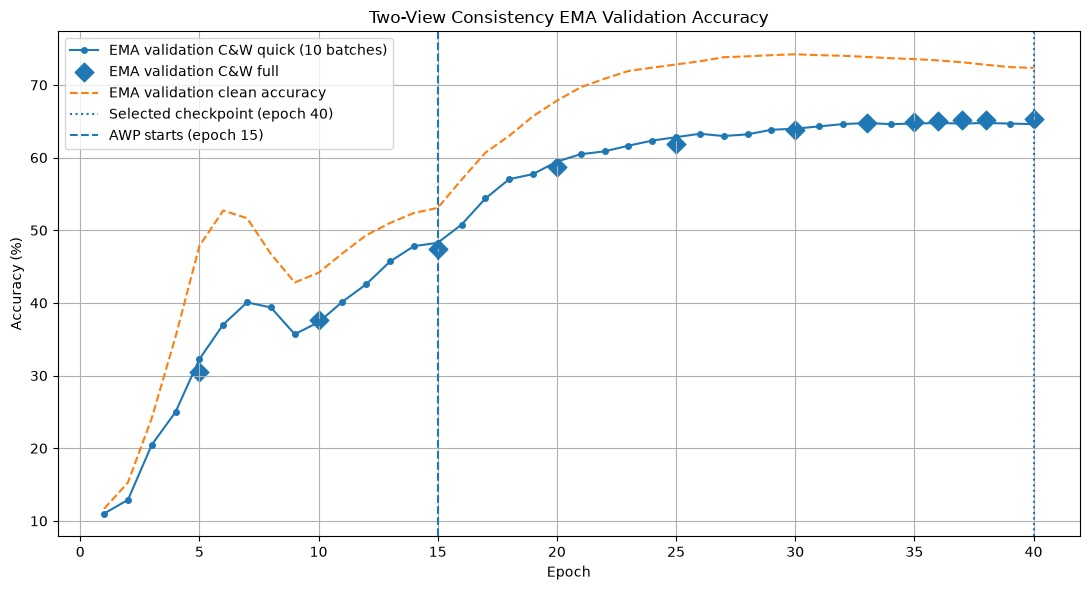

Selected best epoch: 40
Selected full validation C&W accuracy: 0.6528
Epochs with full validation: [5, 10, 15, 20, 25, 30, 33, 35, 36, 37, 38, 40]


In [39]:
if HISTORY_PATH.exists():
    saved_history_data = torch.load(
        HISTORY_PATH,
        map_location="cpu"
    )

    plot_history = (
        saved_history_data["history"]
    )

    selected_best_epoch = (
        saved_history_data.get(
            "best_epoch"
        )
    )

    selected_best_full_accuracy = (
        saved_history_data.get(
            "best_full_robust_acc"
        )
    )

elif (
    "history" in globals()
    and len(
        history[
            "ema_val_quick_robust_acc"
        ]
    ) > 0
):
    plot_history = history

    selected_best_epoch = (
        best_epoch
        if "best_epoch" in globals()
        else None
    )

    selected_best_full_accuracy = (
        best_full_robust_acc
        if (
            "best_full_robust_acc"
            in globals()
        )
        else None
    )

else:
    raise FileNotFoundError(
        f"Training history was not found: "
        f"{HISTORY_PATH}"
    )


quick_robust_history = np.asarray(
    plot_history[
        "ema_val_quick_robust_acc"
    ],
    dtype=float
)

full_robust_history = np.asarray(
    plot_history[
        "ema_val_full_robust_acc"
    ],
    dtype=float
)

clean_history = np.asarray(
    plot_history[
        "ema_val_clean_acc"
    ],
    dtype=float
)

awp_active_history = np.asarray(
    plot_history["awp_active"],
    dtype=bool
)

epochs = np.arange(
    1,
    len(quick_robust_history) + 1
)

valid_full_mask = np.isfinite(
    full_robust_history
)

active_awp_indices = np.flatnonzero(
    awp_active_history
)

if len(active_awp_indices) > 0:
    awp_start_epoch = (
        int(active_awp_indices[0]) + 1
    )
else:
    awp_start_epoch = None


plt.figure(
    figsize=(11, 6)
)

plt.plot(
    epochs,
    quick_robust_history * 100,
    marker="o",
    markersize=4,
    label=(
        "EMA validation C&W quick "
        f"({QUICK_CW_EVAL_BATCHES} batches)"
    )
)

plt.scatter(
    epochs[valid_full_mask],
    (
        full_robust_history[
            valid_full_mask
        ]
        * 100
    ),
    s=90,
    marker="D",
    label=(
        "EMA validation C&W full"
    )
)

plt.plot(
    epochs,
    clean_history * 100,
    linestyle="--",
    label=(
        "EMA validation clean accuracy"
    )
)

if selected_best_epoch is not None:
    plt.axvline(
        selected_best_epoch,
        linestyle=":",
        label=(
            f"Selected checkpoint "
            f"(epoch {selected_best_epoch})"
        )
    )

if awp_start_epoch is not None:
    plt.axvline(
        awp_start_epoch,
        linestyle="--",
        label=(
            f"AWP starts "
            f"(epoch {awp_start_epoch})"
        )
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Two-View Consistency EMA "
    "Validation Accuracy"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


print(
    "Selected best epoch:",
    selected_best_epoch
)

print(
    "Selected full validation C&W "
    "accuracy:",
    selected_best_full_accuracy
)

print(
    "Epochs with full validation:",
    epochs[valid_full_mask].tolist()
)


## Final Evaluation

The best EMA checkpoint is loaded and evaluated on the complete validation and test sets using both clean accuracy and C&W L2 robust accuracy.

In [40]:
if not SAVE_PATH.exists():
    raise FileNotFoundError(
        "Best two-view consistency EMA "
        f"checkpoint was not found: "
        f"{SAVE_PATH}"
    )

best_ema_checkpoint_state = torch.load(
    SAVE_PATH,
    map_location=device
)

model.load_state_dict(
    best_ema_checkpoint_state
)

model = model.to(device)
model.eval()

print(
    "Loaded best two-view consistency "
    f"EMA model from: {SAVE_PATH}"
)


Loaded best two-view consistency EMA model from: /home/ali/Desktop/SUT/AI/adversarial_attacks_and_defenses/checkpoints/resnet20_cifar10_a2_gairat_exponential_beta_0_to_40_consistency_ema0999_best.pth


In [41]:
val_loss, val_clean_acc = (
    evaluate_clean(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device
    )
)

print(
    f"Final Consistency EMA Val Clean Accuracy: "
    f"{val_clean_acc:.4f}"
)

print(
    "Running C&W L2 evaluation "
    "on the full validation set..."
)

# Competitive C&W L2 evaluation on all test images.
val_robust_acc = evaluate_cw_robust(
    model=model,
    loader=val_loader,
    device=device,
    num_steps=CW_TEST_STEPS,
    eval_batches=None
)

print(
    f"Final Consistency EMA Val C&W Robust Accuracy: "
    f"{val_robust_acc:.4f}"
)

Final Consistency EMA Val Clean Accuracy: 0.7234
Running C&W L2 evaluation on the full validation set...
Final Consistency EMA Val C&W Robust Accuracy: 0.6528


In [42]:
# Final evaluation of the selected two-view consistency EMA checkpoint.
test_loss, test_clean_acc = (
    evaluate_clean(
        model=model,
        loader=test_loader,
        criterion=criterion,
        device=device
    )
)

print(
    f"Final Consistency EMA Test Clean Accuracy: "
    f"{test_clean_acc:.4f}"
)

print(
    "Running C&W L2 evaluation "
    "on the full test set..."
)

# Competitive C&W L2 evaluation on all test images.
test_robust_acc = evaluate_cw_robust(
    model=model,
    loader=test_loader,
    device=device,
    num_steps=CW_TEST_STEPS,
    eval_batches=None
)

print(
    f"Final Consistency EMA Test C&W Robust Accuracy: "
    f"{test_robust_acc:.4f}"
)

Final Consistency EMA Test Clean Accuracy: 0.7138
Running C&W L2 evaluation on the full test set...
Final Consistency EMA Test C&W Robust Accuracy: 0.6374
